In [1]:
#Librerias de analisis y visualizacion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerias cargadas correctamente ✓")

Librerias cargadas correctamente ✓


In [3]:
# Cargar el archivo CSV
df = pd.read_csv('/content/ml-churn-prediction-data.csv')

# Ver las primeras filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Cuantas filas y columnas tiene el dataset
print("Forma del dataset:", df.shape)

# Tipos de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# Resumen estadistico de columnas numericas
df.describe

In [4]:
# Revisar si hay valores faltantes
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# TotalCharges viene como texto, hay que convertirla a numero
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Eso genera algunos NaN - los eliminamos
df.dropna(inplace=True)

#Verificar que quedo limpio
print("Valores nulos despues de limpieza:")
print(df.isnull().sum().sum()) # Debe dar 0

Valores nulos despues de limpieza:
0


Distribucion de Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

En porcentaje:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


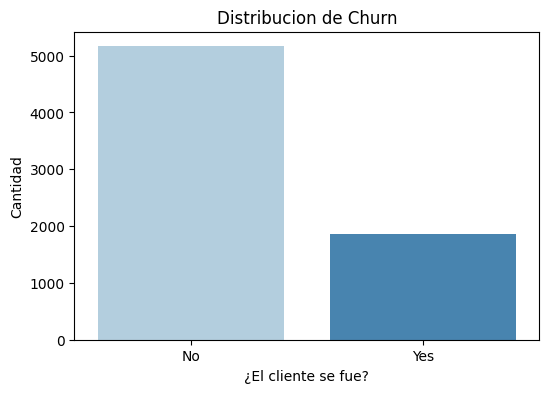

In [7]:
# Cuantos clientes se fueron vs se quedaron
print("Distribucion de Churn:")
print(df['Churn'].value_counts())
print("\nEn porcentaje:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Grafica
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='Blues', legend=False)
plt.title('Distribucion de Churn')
plt.xlabel('¿El cliente se fue?')
plt.ylabel('Cantidad')
plt.show()

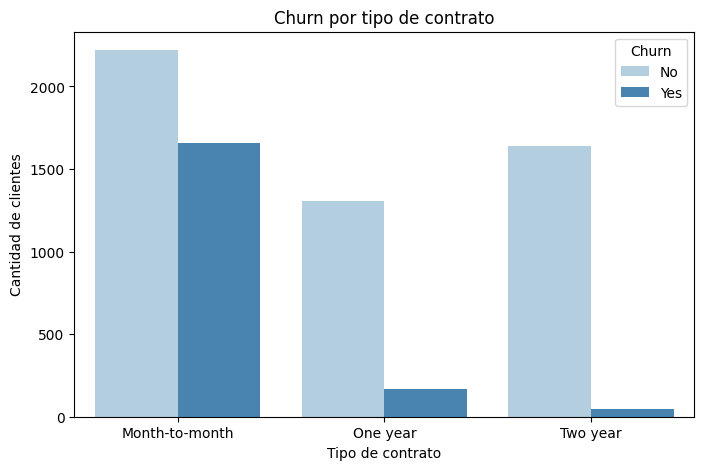

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Blues')
plt.title('Churn por tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Churn')
plt.show()

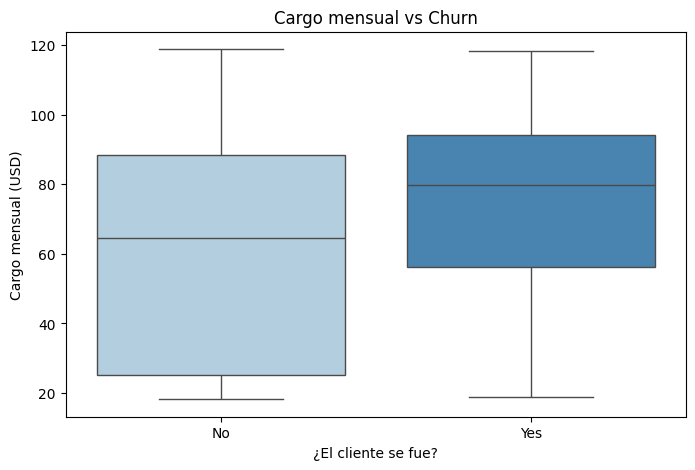

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='Blues', legend=False)
plt.title('Cargo mensual vs Churn')
plt.xlabel('¿El cliente se fue?')
plt.ylabel('Cargo mensual (USD)')
plt.show()

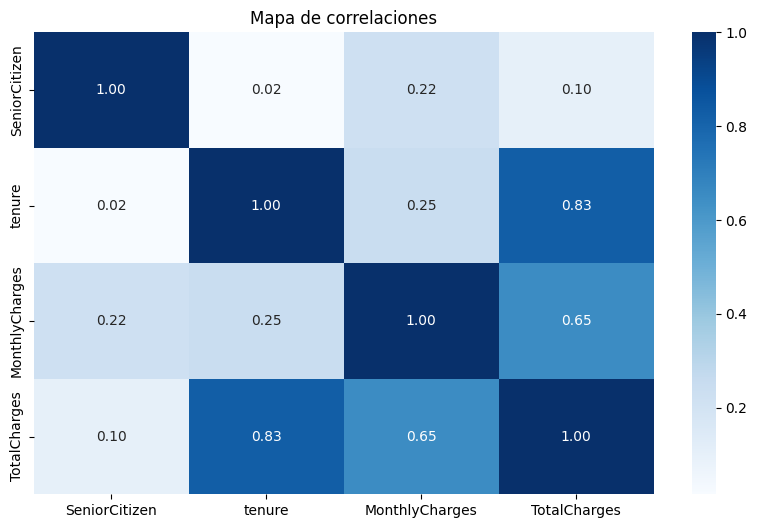

In [12]:
# Solo columnas numericas
numericas = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Mapa de correlaciones')
plt.show()